In [7]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import datasets,layers,models
import os
import random

In [8]:
ClassNames = ['Aircraft Carrier', 'Bulkers', 'Car Carrier', 'Container Ship', 'Cruise', 'DDG', 'Recreational', 'Sailboat', 'Submarine', 'Tug']

In [9]:
data_image = '/kaggle/input/ships-dataset/Ships dataset/train/images'
data_label = '/kaggle/input/ships-dataset/Ships dataset/train/labels'
traindata = []
pathi = os.path.join(data_image)
pathl = os.path.join(data_label)

for file in os.listdir(pathi):
    file_p  = os.path.join(pathi, file)
    image = cv2.imread(file_p)
    image = np.array(image)
    image=cv2.resize(image, (64,64),interpolation=cv2.INTER_LINEAR)
    traindata.append(image)
    
    

In [10]:
trainlabel = []
for file in os.listdir(pathl):
    file_p  = os.path.join(pathl, file)
    f = open(file_p, "r")
    a = int(f.read(1))
    trainlabel.append(a)

In [11]:
data = []
for i in range(0,len(trainlabel)):
    traindata[i] = traindata[i]/255
    data.append((traindata[i], trainlabel[i]))

random.shuffle(data)
images, labels =  [], []
for a, b in data:
    images.append(a)
    labels.append(b)
    


# **Visualize the Data**

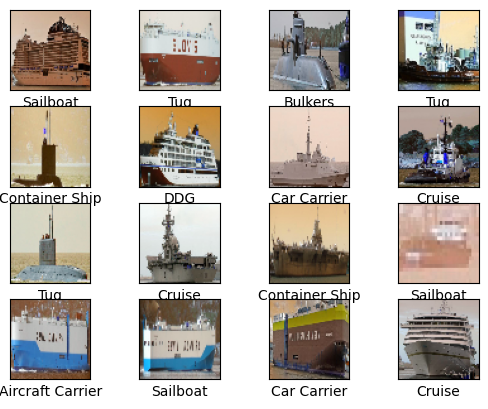

In [12]:
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(images[i],cmap=plt.cm.binary)
    plt.xlabel(ClassNames[labels[i]])
plt.show()

# **Importing Validation Data**

In [13]:
data_image = '/kaggle/input/ships-dataset/Ships dataset/valid/images'
data_label = '/kaggle/input/ships-dataset/Ships dataset/valid/labels'
validdata = []
pathi = os.path.join(data_image)
pathl = os.path.join(data_label)

for file in os.listdir(pathi):
    file_p  = os.path.join(pathi, file)
    image = cv2.imread(file_p)
    image = np.array(image)
    image=cv2.resize(image, (64,64),interpolation=cv2.INTER_LINEAR)
    validdata.append(image)
    
validlabel = []
for file in os.listdir(pathl):
    file_p  = os.path.join(pathl, file)
    f = open(file_p, "r")
    a = int(f.read(1))
    validlabel.append(a)
    
validation = []
for i in range(0,len(validlabel)):
    validdata[i] = validdata[i]/255
    validation.append((validdata[i], validlabel[i]))

random.shuffle(validation)
validationimages, validationlabels =  [], []
for a, b in validation:
    validationimages.append(a)
    validationlabels.append(b)

In [14]:
images = np.array(images)
labels = np.array(labels)
validationimages = np.array(validationimages)
validationlabels = np.array(validationlabels)

In [15]:
model = models.Sequential()
model.add(layers.Conv2D(64,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.fit(images,labels,batch_size = 32,epochs=20,validation_data=(validationimages,validationlabels))

loss, accuracy = model.evaluate(images,labels)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

Epoch 1/20
 30/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2158 - loss: 2.2660

I0000 00:00:1719224291.319357     109 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


232/232 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.2267 - loss: 2.2086 - val_accuracy: 0.2598 - val_loss: 2.2189
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2392 - loss: 2.1644 - val_accuracy: 0.2598 - val_loss: 2.2021
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2432 - loss: 2.1597 - val_accuracy: 0.2598 - val_loss: 2.4247
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2371 - loss: 2.1608 - val_accuracy: 0.2569 - val_loss: 2.5864
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2386 - loss: 2.1579 - val_accuracy: 0.2569 - val_loss: 2.5342
Epoch 6/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2438 - loss: 2.1572 - val_accuracy: 0.2583 - val_loss: 2.9719
Epoch 7/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2421 - loss: 2.1494 - val_accuracy: 0.2540 - val_loss: 3.9460
Epoch 8/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2394 - loss: 2.1316 - val_accuracy: 0.2540 - va

In [17]:
model.save('ShipClassifierV1.h5')


In [18]:
model = models.load_model('ShipClassifierV1.h5')

In [19]:
data_image = '/kaggle/input/ships-dataset/Ships dataset/test/images'
data_label = '/kaggle/input/ships-dataset/Ships dataset/test/labels'
testdata = []
pathi = os.path.join(data_image)
pathl = os.path.join(data_label)

for file in os.listdir(pathi):
    file_p  = os.path.join(pathi, file)
    image = cv2.imread(file_p)
    image = np.array(image)
    image=cv2.resize(image, (64,64),interpolation=cv2.INTER_LINEAR)
    testdata.append(image)
    
testlabel = []
for file in os.listdir(pathl):
    file_p  = os.path.join(pathl, file)
    f = open(file_p, "r")
    a = int(f.read(1))
    testlabel.append(a)
    
testing = []
for i in range(0,len(testlabel)):
    testdata[i] = testdata[i]/255
    testing.append((testdata[i], testlabel[i]))

random.shuffle(testing)
testingimages, testinglabels =  [], []
for a, b in testing:
    testingimages.append(a)
    testinglabels.append(b)
    
testinglabels = np.array(testinglabels)
testingimages = np.array(testingimages)

In [20]:
loss, accuracy = model.evaluate(testingimages,testinglabels)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.1586 - loss: 2.7730
Loss: 2.8817100524902344
Accuracy: 0.1784776896238327


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


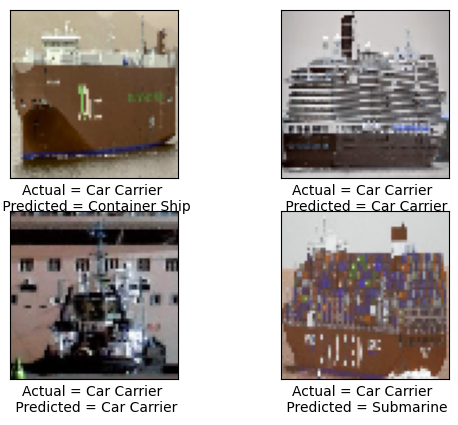

In [21]:
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(testingimages[i],cmap=plt.cm.binary)
    pred = model.predict(np.array([testingimages[i]]))
    index = np.argmax(pred)
    plt.xlabel(f"Actual = {ClassNames[testinglabels[i]]} \n Predicted = {ClassNames[index]}")
    
plt.show()